In [4]:
# ImpulseGuard — Step 1
# Environment Test

import sys
import tensorflow as tf
import librosa
import numpy as np
import scipy
import soundfile as sf
import matplotlib.pyplot as plt

print("✅ Python:", sys.version.split()[0])
print("✅ TensorFlow:", tf.__version__)
print("✅ Librosa:", librosa.__version__)
print("✅ NumPy:", np.__version__)
print("✅ SciPy:", scipy.__version__)
print("✅ SoundFile:", sf.__version__)

print("\n🎉 ImpulseGuard ML environment is working!")

I0000 00:00:1788274462.208840    7692 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788274463.007463    7692 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788274465.002770    7692 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ Python: 3.13.7
✅ TensorFlow: 2.21.0
✅ Librosa: 1.0.0
✅ NumPy: 2.5.2
✅ SciPy: 1.18.1
✅ SoundFile: 0.14.0

🎉 ImpulseGuard ML environment is working!


In [5]:

audio, sr = librosa.load(
    "../data/tests/speech1.wav",
    sr=None,
    mono=False
)

print("Sample rate:", sr)
print("Shape:", audio.shape)

Sample rate: 44100
Shape: (2, 2136306)


In [6]:
print(audio[:20])
print(type(audio))
print(audio.dtype)

[[-0.0118103   0.00082397 -0.00524902 ...  0.03591919  0.04284668
   0.03427124]
 [-0.01239014 -0.00222778 -0.00741577 ...  0.09320068  0.10546875
   0.0838623 ]]
<class 'numpy.ndarray'>
float32


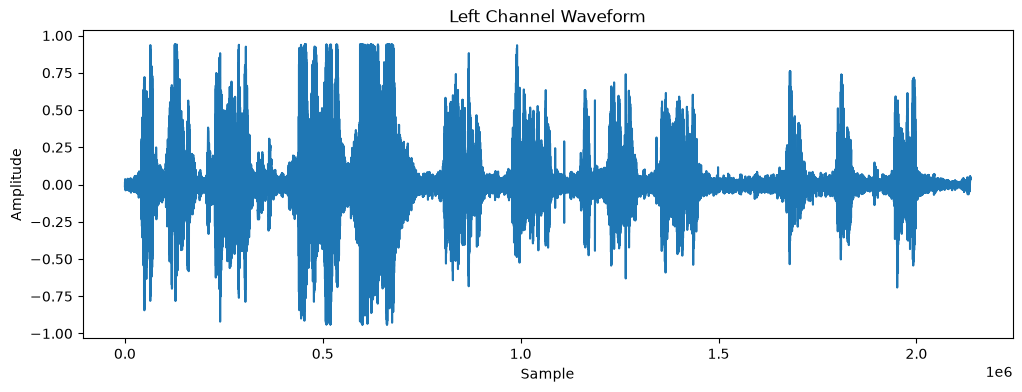

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(audio[0])

plt.title("Left Channel Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [8]:
print("Number of channels:", audio.shape[0])
print("Samples per channel:", audio.shape[1])
print("Sample rate:", sr)

duration = audio.shape[1] / sr
print("Duration:", duration, "seconds")

Number of channels: 2
Samples per channel: 2136306
Sample rate: 44100
Duration: 48.44231292517007 seconds


In [9]:
mono_audio = librosa.to_mono(audio)

print("Original shape:", audio.shape)
print("Mono shape:", mono_audio.shape)

Original shape: (2, 2136306)
Mono shape: (2136306,)


In [10]:
print("First 10 mono samples:")
print(mono_audio[:10])
print("Mono dtype:", mono_audio.dtype)

First 10 mono samples:
[-0.01210022 -0.0007019  -0.0063324  -0.00636292 -0.00643921 -0.00308228
 -0.00082397 -0.00080872 -0.00265503 -0.0025177 ]
Mono dtype: float32


In [11]:
audio_16k = librosa.resample(
    mono_audio,
    orig_sr=sr,
    target_sr=16000
)

print("Original sample rate:", sr)
print("New sample rate:", 16000)
print("Original samples:", len(mono_audio))
print("New samples:", len(audio_16k))

Original sample rate: 44100
New sample rate: 16000
Original samples: 2136306
New samples: 775078


In [12]:
print("Final sample rate: 16000 Hz")
print("Final channels: 1")
print("Final samples:", len(audio_16k))
print("Final duration:", len(audio_16k) / 16000, "seconds")

Final sample rate: 16000 Hz
Final channels: 1
Final samples: 775078
Final duration: 48.442375 seconds


In [13]:
import soundfile as sf

sf.write(
    "../data/tests/processed.wav",
    audio_16k,
    16000,
    subtype="PCM_16"
)

print("✅ Saved processed.wav")

✅ Saved processed.wav


In [14]:

data, sample_rate = sf.read("../data/tests/processed.wav")

print("Sample rate:", sample_rate)
print("Shape:", data.shape)
print("Data type:", data.dtype)
print("Duration:", len(data) / sample_rate, "seconds")

Sample rate: 16000
Shape: (775078,)
Data type: float64
Duration: 48.442375 seconds


In [15]:
rms = np.sqrt(np.mean(audio_16k ** 2))
power = np.mean(audio_16k ** 2)

print("RMS:", rms)
print("Power:", power)
print("RMS²:", rms ** 2)

RMS: 0.11327321
Power: 0.012830821
RMS²: 0.01283082


In [ ]:
noise, noise_sr = librosa.load(
    "../data/tests/noise.wav",
    sr=None,
    mono=False
)

print("Noise sample rate:", noise_sr)
print("Noise shape:", noise.shape)

LibsndfileError: Error opening '../data/test/noise.wav': System error.